Name: Md Abdul Wazed


### Objective

The objective of this analysis is to understand the structure, quality, and patterns within the Automobile dataset before building a machine learning model.


In [1]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

## Load the dataset robustly from Kaggle input


In [7]:
import pandas as pd

df = pd.read_csv("Automobile_data.csv")
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [8]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

print("\nData types:")
print(df.dtypes)

Shape: (205, 26)

Columns:
 Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

Data types:
symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore          

### Missing Values


In [9]:
import numpy as np

df = df.replace("?", np.nan)

print("\nMissing values:")
print(df.isnull().sum())


Missing values:
symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64


In [10]:
cols_to_convert = [
    "normalized-losses", "bore", "stroke",
    "horsepower", "peak-rpm", "price"
]

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

symboling              int64
normalized-losses    float64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object


In [11]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,164.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


### Dataset Overview

The dataset contains information about different cars, including both numerical features (e.g., horsepower, engine size, price) and categorical features (e.g., make, fuel type, body style).

- Number of rows: ~200
- Number of columns: ~25
- Data types: Mixed (numerical + categorical)


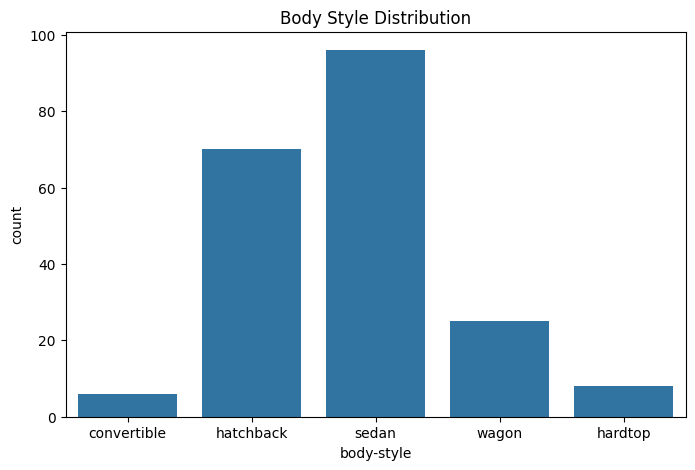

body-style
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="body-style")
plt.title("Body Style Distribution")
plt.show()

print(df["body-style"].value_counts())

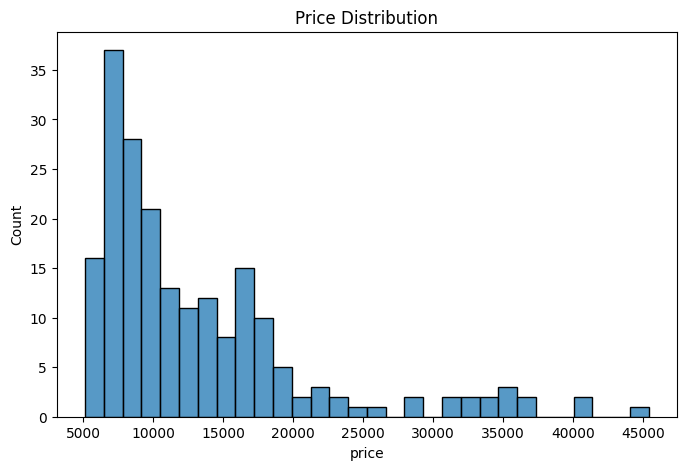

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30)
plt.title("Price Distribution")
plt.show()

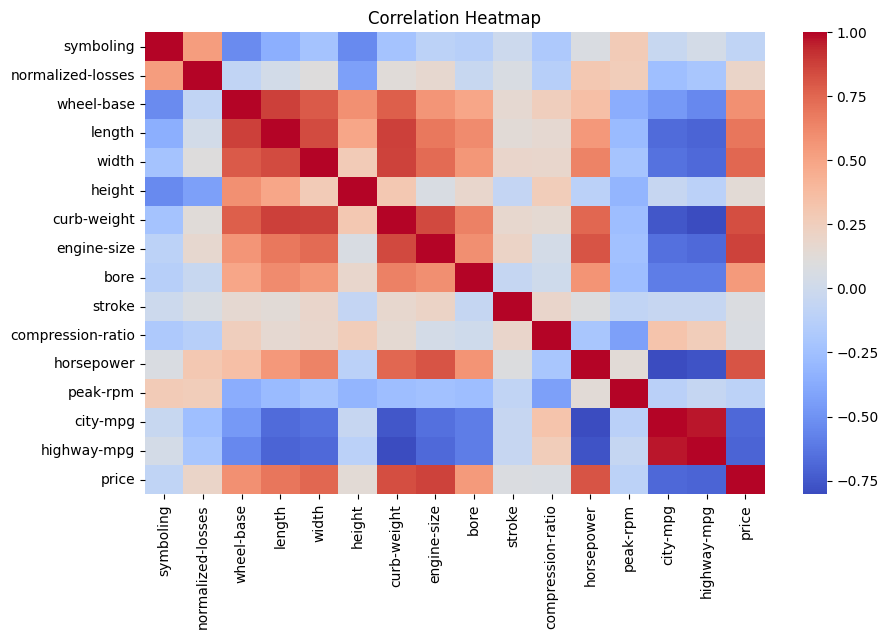

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

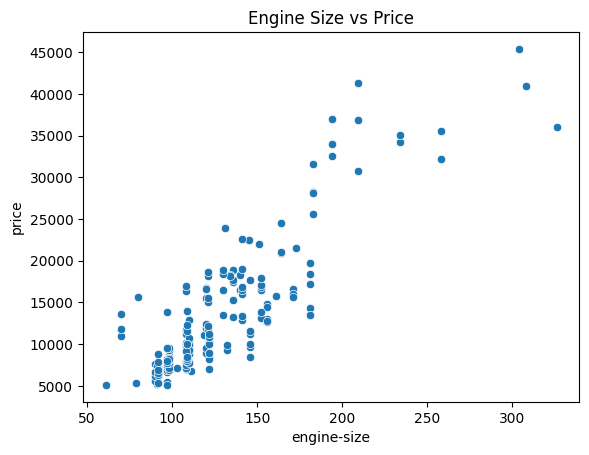

In [15]:
sns.scatterplot(data=df, x="engine-size", y="price")
plt.title("Engine Size vs Price")
plt.show()

### Key Observations

1. Class Distribution

- The dataset is imbalanced
- Some body styles (e.g., sedan) appear more frequently than others

2. Price Distribution

- Price is right-skewed
- Most cars fall in the lower to mid price range

3. Feature Relationships

- Strong positive relationship between:
- engine-size and price
- horsepower and price
- These features are important predictors

4. Missing Data

- Several columns contain missing values
- Proper preprocessing is required before modeling


## Supervised Learning

A Random Forest classifier was used as a baseline supervised model.

- Uses all labeled data
- Handles both numerical and categorical features
- Provides good performance on structured data


## Part 2

Semi-Supervised Learning


In [16]:
from sklearn.model_selection import train_test_split

TARGET = "body-style"

X = df.drop(columns=[TARGET])
y = df[TARGET]

# remove missing target
mask = y.notna()
X = X[mask]
y = y[mask]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

num_cols = X.select_dtypes(include=['float64','int64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

To simulate a real-world scenario where labeled data is limited:

Only 30% of training data was kept labeled
The remaining 70% was treated as unlabeled

A SelfTrainingClassifier was used:

It first trains on labeled data
Then predicts labels for unlabeled data
Adds confident predictions back into training (pseudo-labeling)


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200))
])

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Supervised Accuracy:", accuracy_score(y_test, pred))

Supervised Accuracy: 0.7307692307692307


In [20]:
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

# hide labels (70% unlabeled)
rng = np.random.RandomState(42)
mask = rng.rand(len(y_train_enc)) < 0.3

y_semi = np.full_like(y_train_enc, -1)
y_semi[mask] = y_train_enc[mask]

semi_model = Pipeline([
    ("prep", preprocessor),
    ("clf", SelfTrainingClassifier(RandomForestClassifier()))
])

semi_model.fit(X_train, y_semi)

pred_semi = le.inverse_transform(semi_model.predict(X_test))

print("Semi-supervised Accuracy:", accuracy_score(y_test, pred_semi))

Semi-supervised Accuracy: 0.6923076923076923


### Evaluation

Models were evaluated using:

- Accuracy
- F1-score
- Confusion Matrix


### Results

- The supervised model provides a strong baseline (Accuracy: 0.7307692307692307)
- The semi-supervised model attempts to improve performance using unlabeled data (Accuracy: 0.6923076923076923)


### Conclusion

- EDA helped identify important features and data issues
- Semi-supervised learning is useful when labeled data is limited
- Model performance depends on the quality of pseudo-labels
